--- 
title: Texture Networks
subtitle: A neural network approach to synthesize textures and performing Neural Style Transfer
authors: - admin
date: 11-01-2019
---

**Texture Networks** is a Neural Network approach devised by Dmitry Ulyanov, Vadim Lebedev, Andrea Vedaldi and Victor Lempitsky in 2016, which is extremely useful to synthesize new types of textures (which is extensively used in production of clothings with exclusive designs), as well as being able to work as a style transfer mechanism.


## What is Neural Style Transfer?

I think the answer to this question is better to show visually, rather than talking about it.

<img src="./out1.png"/>

<img src="./out2.png"/>

<img src="./out3.png"/>


So, I think now one should get the idea. Neural Style transfer combines the aesthestics of an image on to another image (here the image of the girl named Karya, which has been provided by [Dmitry Ulyanov's Github](https://github.com/DmitryUlyanov/texture_nets)), retaining the content of the image (i.e. retaining the girl in the stylized output). Note that, the effect is particularly visible in 2nd and 3rd images, whereas, for first image, the style aspect is greatly emphasized.

I am going to discuss exactly how I created those stylized images, and hopefully, after reading this, you would be able to reproduce similar results with images of your choice.


## Prerequisites

I am not talking about things you need to know beforehand to understand intricate details of the mechanism, but the software requirements that I will be using to create something similar to texture networks. So, at the very beginning, I import all required packages in `python`. Also, I shall be using a **NVidia GeForce GTX 1060Ti** Graphics card with CUDA computing capability 6.1, which is not at par with the GPU devices used at professional level, but this speeds up the computations by a lot rather than using a CPU.

In [2]:
import tensorflow as tf
import numpy as np
import time
import functools
import PIL.Image
import IPython.display as display
import matplotlib.pyplot as plt

In [3]:
tf.__version__

'2.1.0-rc0'

In [4]:
tf.test.gpu_device_name()

'/device:GPU:0'

## Making Some Utility Functions

Before proceeding with describing how the Texture Network is created, I would create some utility functions to help us later. For instance, this utility functions will allow us to load images from a path, and visualize an image given its tensor.


### What is a tensor?

Let us revisit some high school mathematics for a bit. We know that matrix is an 2-dimensional array of numbers, if simply put. [Tensor](https://en.wikipedia.org/wiki/Tensor) is a generalization of that, it is an n-dimensional array. 

Now, when a mathematician introduces matrix, it is essentially an efficient way of representing linear functions from a vector space to another vector space. A **Vector Space** is a space comprised of vectors, and a vector is something that satisfies some mathematical properties. But, we don't need that. Think of vectors in the most simple way, it is something that has a magnitude and a direction, like speed.

Coming back to tensor, it is introduced as an efficient representation of **Multilinear Maps** between vector spaces. Let $V_1, V_2, \dots V_n, W$ be some vector spaces, then, a function $f : V_1 \times V_2 \times\dots V_n \rightarrow W$ is said to be multilinear map, if $f(v_1, v_2, \dots v_i, \dots v_n)$ is linear in $v_i$ given all other arguments $v_1, \dots v_{i-1}, v_{i+1}, \dots v_n$ are fixed. And such linearity holds of any of its arguments. So, if you know mathematics of Linear Algebra and Matrices, then you would clearly understand that tensor is just a multidimensional generalization of matrices.


### What an Image is do to with Tensor?

Now, to understand how tensor comes into play to define images, one needs to understand the mechanism of how an image is stored digitally. For this, consider a black grid like chessboard, but all cells are coloured white. Now, you start colouring some cells to black, and then you would be able to generate some pictures with tons of block like artifacts. The following example from [logicalzero.com](http://logicalzero.com/gamby/reference/image_formats.html) shows such a smiley face just colouring a 8x8 grid.

<img src="./smiley.png"/>

A smiley was okay, but it was not very appealing. Now, since we have a 8x8 grid, and each of the cells can be coloured in 2 ways, black or white. Hence, by simple combinatorics, this generates $2^{256}$ possible images, out of this 8x8 grid, which is about $1.15 \times 10^{77}$. That's a lot! However, not all such combinations will result in visually appealing images, something that we can actually call as a potential image with our natural sense. So, among these vast majority of combinations, only a few will make up images, that our brain can visualize and understand as an image.

However, if we wish to create more complicated images, we need a bigger grid. The reason being that these 8x8 grid cannot be used to approximate complicated curves in the image we encounter in daily life. For instance, increasing the number of cells in the grid, we can create an image of a panda.

<img src="nonogram.png">

*Note: This image transpires as a solution of a puzzle called [Nonogram](https://en.wikipedia.org/wiki/Nonogram), which is also called as Picross or Visual Crosswords or Japanese Crosswords.*

Using finer grids actually results in a better picture, as you can see. Digital black and white images are represented using the technique described above, and each of the grid cell is called a [Pixel](https://en.wikipedia.org/wiki/Pixel). Now, note that, we can represent this grid using a 2-dimensional matrix of 0's and 1's, where a white pixel would be represented as 0 and a black pixel would be repesented as 1. For instance, the smiley image can be matrixified like this:

<div style="width: 500px; margin:auto;">
<img src="./smiley.png" style="float:left;"/>

<div style = "float:right; width: 250px;">
    $$\begin{bmatrix}
    0 & 0 & 1 & 1 & 1 & 1 & 0 & 0\\
    0 & 1 & 0 & 0 & 0 & 0 & 1 & 0\\
    1 & 0 & 1 & 0 & 1 & 0 & 0 & 1\\
    1 & 0 & 1 & 0 & 1 & 0 & 0 & 1\\
    1 & 0 & 0 & 0 & 0 & 1 & 0 & 1\\
    1 & 0 & 1 & 1 & 1 & 0 & 0 & 1\\
    0 & 1 & 0 & 0 & 0 & 0 & 1 & 0\\
    0 & 0 & 1 & 1 & 1 & 1 & 0 & 0\\
    \end{bmatrix}$$
</div>
</div>

Now, we shall use colour images in this context of Neural Style Transfer. To represent a colour image, we require 3 such matrices. One for Red channel, one for Blue channel and another for Green Channel. Also, the elements of the matrices will be allowed to take values between 0 and 255 (to be represented by 8 digit binary numbers) or to take any real value between 0 and 1, representing the denisty of the colour. For instance, in the above black and white images, we can put the value 0.5 in some elements to represent that those pixels should be coloured using gray, which is a colour midway between black and white. Hence, allowing floating point values would ensure a richer distribution of images.

Coming back to the link between images and tensor, an image is represented by 3 such matrices, in combination, a 3-dimensional tensor, which the dimension or shape being (3, height of the image, width of the image), where 3 being number of channels.

In [5]:
def tensor_to_image(tensor):
    tensor = tf.clip_by_value(tensor, clip_value_min=0.0, clip_value_max=255.0)
    tensor = np.array(tensor, dtype=np.uint8)   # convert tf array to np array of integers
    if np.ndim(tensor)>3:
        assert tensor.shape[0] == 1  # asserts that the BATCH_SIZE = 1
        tensor = tensor[0]   # take the first image
    return PIL.Image.fromarray(tensor)

In [6]:
def load_img(path_to_img, rescale = False):
    # we rescale the image to max dimension 256 for fasters processing
    max_dim = 256    
    img = tf.io.read_file(path_to_img)   # read the image
    img = tf.image.decode_image(img, channels=3)    # decode into image content
    img = tf.image.convert_image_dtype(img, tf.float32)    # convert to float
    
    if rescale:
        img = tf.image.resize(img, tf.constant([max_dim, max_dim]))
    else:
        shape = tf.cast(tf.shape(img)[:-1], tf.float32)   
        # get the shape of image, cast it to float type for division, expect the last channel dimension
        long_dim = max(shape)
        scale = max_dim / long_dim    # scale accordingly
        new_shape = tf.cast(shape * scale, tf.int32)   # cast the new shape to integer
        img = tf.image.resize(img, new_shape)   # resize image
        
    img = img[tf.newaxis, :]   # newaxis builts a new batch axis in the image at first dimension
    return img

In [7]:
style_path = '../input/artistic-style-transfer/pattern-rooster.jpg'
content_path = '../input/artistic-style-transfer/celebGAN_male.png'

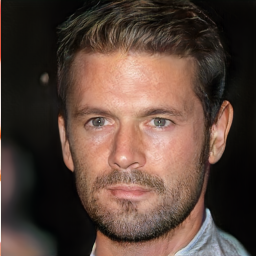

In [8]:
content_image = load_img(content_path, rescale = True)
tensor_to_image(content_image * 255.0)

This is the content image, on which we shall apply some style. Note that, the loaded images have elements between 0 and 1, while the `tensor_to_img` function takes in a tensor with values between 0 and 255, hence we need to multiply all the elements by 255 to convert it to the crucial range where it can be visualized. 

Surprisingly, the image I am using is actually an image generated via Neural Network called [Progressive GAN](https://arxiv.org/abs/1710.10196), which is really interesting work by Tero Karras, Timo Aila, Samuli Laine, Jaakko Lehtinen, who trained a network on **Celeb A** dataset to generate images of new celebrities, who do not exist in real life. 

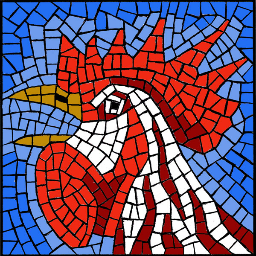

In [9]:
style_image = load_img(style_path, rescale = False)
tensor_to_image(style_image * 255.0)

This is the style image that we can going to use. So, we think, the final image would look like the image of the artificial celebrity, tessalatted like the style image.


# Architecture of Texture Network

Texture Network comprised of two main components.

1. A Generator Network.
2. A Descriptor Network.

A **Generator Network** is a neural network which takes input of the content image and some random noise, and output our desired stylized image.

A **Descriptor Network** is a neural network which takes input of the desired stylized image, and then try to figure out the underlying style and content of the stylized image, and try to match it with the original style image and content image.

If you are familiar with [Generative Adversarial Networks](https://en.wikipedia.org/wiki/Generative_adversarial_network) (GAN), then you would find a lot similarity of Texture Network with GANs. However, unlike to the case of GAN, here, the descriptor network will not be trained, but will be used to measure the style and content of the stylized images generated by Generator Network.

To understand why such a descriptor network is needed at all, consider an image of a person. If one shifts the image just by one pixel to the left, then using a simple squared error loss between the original image and shifted image would become large, however, from our perception, both images would look identical. Hence, to actually compare the two images, we specifically need to compare high level representations of the images, which will be provided by the descriptor network.

<img src="texnet.png">


## Choice of Descriptor Network

We use [VGG19](https://arxiv.org/abs/1409.1556) as our descriptor network as it is a Very Deep Convolutional Networks for Large-Scale Image Recognition. It was developed by Karen Simonyan, Andrew Zisserman in 2014, and is trained with the ImageNet dataset, comprising of millions of images. Hence, high level features of this network will be an acurate representation of the style and content of images.

In [10]:
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')   # Load VGG19 pretrained Network from Keras

print()
for layer in vgg.layers:
    print(layer.name)   # print layer names so that we can reference them later

80142336/80134624 [==============================] - 1s 0us/step

input_1
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_conv4
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_conv4
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_conv4
block5_pool


Note that, VGG19 has a sturcture called a Convolutional Block. Each such block consists of 5 layers of neuron, the first 4 layers being convolutional layers, and the last layers being a pooling layer. The top layer which was excluded from the loaded model is specifically a hidden dense layer that connects the final pooled layer to the output layer, which outputs the classification of the Imagenet image. However, we do not need this final hidden dense layer.

## Creating Generator Network

To build the generator network, we need something called a Circular Convolution. To understand various convolutional arithmetic properly, I would recommend checking out the following resources.

1. https://github.com/vdumoulin/conv_arithmetic contains a simple animation showing convolutions with different parameters.
2. https://ezyang.github.io/convolution-visualizer/index.html has a really good interactive environment where you can set the parameters and take look at the corresponding convolutional operation.

Coming back to circular convolution, it is a simple 2-dimensional convolution with with a particular type of padding called **Circular Padding**. It essentially wraps the image from top to bottom and from left to right.

In [11]:
def periodic_padding(x, padding=1):
    '''
    x: shape (batch_size, d1, d2)
    return x padded with periodic boundaries. i.e. torus or donut
    '''
    d1 = x.shape[1] # dimension 1: height
    d2 = x.shape[2] # dimension 2: width
    p = padding
    # assemble padded x from slices
    #            tl,tc,tr
    # padded_x = ml,mc,mr
    #            bl,bc,br
    top_left = x[:, -p:, -p:] # top left
    top_center = x[:, -p:, :] # top center
    top_right = x[:, -p:, :p] # top right
    middle_left = x[:, :, -p:] # middle left
    middle_center = x # middle center
    middle_right = x[:, :, :p] # middle right
    bottom_left = x[:, :p, -p:] # bottom left
    bottom_center = x[:, :p, :] # bottom center
    bottom_right = x[:, :p, :p] # bottom right
    top = tf.concat([top_left, top_center, top_right], axis=2)
    middle = tf.concat([middle_left, middle_center, middle_right], axis=2)
    bottom = tf.concat([bottom_left, bottom_center, bottom_right], axis=2)
    padded_x = tf.concat([top, middle, bottom], axis=1)
    return padded_x

In the function `periodic_padding`, we give several input images, however, with only one channel for each image. Here, the input is a tensor of the shape (number of images, height of the image, width of the image). Hence, we can think of the input as if we are passing many 2-dimensional matrices of shape (height of the image, width of the image). We also pass the amount of padding that we want. Let us see what it outputs, when we pass a single 2D matrix as follows;

$$\begin{bmatrix}
1 & 2 & 3\\
4 & 5 & 6\\
7 & 8 & 9\\
\end{bmatrix}$$

In [12]:
a = tf.constant([[[1, 2, 3], [4, 5, 6], [7, 8, 9]]])
periodic_padding(a)

<tf.Tensor: shape=(1, 5, 5), dtype=int32, numpy=
array([[[9, 7, 8, 9, 7],
        [3, 1, 2, 3, 1],
        [6, 4, 5, 6, 4],
        [9, 7, 8, 9, 7],
        [3, 1, 2, 3, 1]]], dtype=int32)>

Note that, the output tensor has size 5x5, which it obtained by one unit of padding in top, bottom, left and right. Also note that, to the left of 1, we have 3, hence it is as if the rightmost column of the original matrix is wrapped to the left side of the matrix. Similar wrapping is also seen in vertical direction.

However, for an image, we need to perform this circular padding for each of the channel. Hence, we first split up the 3 channels of the image, then append circular padding for each one, and finally combine them together. This is done through `CircularPadding` function.

In [13]:
def CircularPadding(inputs, kernel_size = 3):
    """Prepares padding for Circular convolution"""
    # split all the filters
    n_filters_in = inputs.shape[-1]
    input_split = tf.split(inputs, n_filters_in, axis = -1)
    output_split = []
    for part in input_split:
        part = tf.squeeze(part, axis = -1)
        outs = periodic_padding(part, padding = int(kernel_size / 2))
        outs = tf.expand_dims(outs, axis = -1)
        output_split.append(outs)
    return tf.concat(output_split, axis = -1)

<img src="convolution.png" width = "500px">

The diagram above shows the main idea of a convolutional layer. Let us say, we have an image, represented by a 5x5x3 tensor (pretty bad for visualizing, but pretty good for understanding), and we wish to perform convolution of this image with a 3x3 kernel. Then the convolution is basically a weighted combination of all the neighbouring pixels from all the layers. To understand mathematically, let us introduce some notations.

Let $X$ denote the tensor image, and $X_{ijc}$ denote the value of the $(i, j)$-th pixel at the $c$-th channel. Now, let us say we wish to find out the value of the convolution at $(i_0, j_0)$ cell. Then, the convolution is defined as;

$$H(i_0, j_0) = b + \sum_{(i, j) \in N(i_0, j_0)}\sum_{c} X_{ijc} K((i - i_0), (j - j_0), c)$$

where $K(\cdot, \cdot, \cdot)$ is kernel weights i.e. some parameters of the network which the network is going to learn. Also, the parameter $b$ is the bias term and $N(i_0, j_0)$ is a neighbourhood of the pixel $(i_0, j_0)$. Therefore, if we have an image with $n$ channels, and we convolute a $k\times k$ kernel on it, then we specifically require $(k^2n + 1)$ parameters including a bias term. 

### Why do we need Convolution?

To understand convolution better, consider two vectors $\textbf{x} = [x_1, x_2, \dots x_n]$ and $\textbf{y} = [y_1, y_2, \dots y_n]$, then the dot product between them is defined as;

$$\textbf{x}\cdot\textbf{y} = \sum_{k=1}^{n} x_ky_k$$

That's high school algebra. However, we also know that, dot product measures the similarity between the vectors $\textbf{x}$ and $\textbf{y}$, i.e. it is maximum when $\textbf{x},\textbf{y}$ are collinear, and is minimum when these are orthogonal to each other. Note that, the above formula of convolution exactly looks like the formula of a dot product, hence it measures the similarity between the patch of the image and the kernel that we have.

Now suppose, we have a kernel that looks like as follows:

$$K = \begin{bmatrix}
-1 & 1 & -1\\
-1 & 1 & -1\\
-1 & 1 & -1\\
\end{bmatrix}$$

Then, if we convolute the image with this kernel, then it attains maximum value when we have a horizontal line, and it will attain minimum value when we have a vertical line. Hence, the convolution will tell us the presence of horizontal and vertical edges in the images, hence will provide combined information or featurs about the images to next level. Similar lower level features can again be convoluted to give rise to higher level features. 

It should also be ntoeworthy that each such result of convolution will tells about existence of one particular feature in the image. Hence, to effectively use it, we shall need to learn many such features, which in the literature of **Image Processing** is described as filters.

Coming back to the Design of Generator of Texture Network, we need several blocks. There are mainly two types of blocks.

1. **Convolutional Block:** It takes the input tensor (may be image or may be features processed in lower level of the network), and performs some Circular Convolution to process the tensor further and obtain some higher level features.

2. **Join Block:** It takes the lower resolution tensor and a high resolution processed noise tensor as input, then it upsamples the lower resolution tensor to match the shape of the high resolution noise and finally merges them together. This noise actually allows the image to have very delicate and intricate variation in the image, as well as create the effect of increment of resolution. 


### Designing Convolutional Block

In [15]:
def conv_block(input_size, in_filters, out_filters):
    """Implements the convolutional block with 3x3, 3x3, 1x1 filters, with proper batch normalization and activation"""
    inputs = tf.keras.layers.Input((input_size, input_size, in_filters, ))   # in_filters many channels of input image
    
    # first 3x3 conv
    conv1_pad = tf.keras.layers.Lambda(lambda x: CircularPadding(x))(inputs)
    conv1_out = tf.keras.layers.Conv2D(out_filters, kernel_size = (3, 3), strides = 1, 
                                       padding = 'valid', name = 'conv1')(conv1_pad)
    hidden_1 = tf.keras.layers.BatchNormalization()(conv1_out)
    conv1_out_final = tf.keras.layers.LeakyReLU(name = 'rel1')(hidden_1)
    
    # second 3x3 conv
    conv2_pad = tf.keras.layers.Lambda(lambda x: CircularPadding(x))(conv1_out_final)
    conv2_out = tf.keras.layers.Conv2D(out_filters, kernel_size = (3, 3), strides = 1, 
                                       padding = 'valid', name = 'conv2')(conv2_pad)
    hidden_2 = tf.keras.layers.BatchNormalization()(conv2_out)
    conv2_out_final = tf.keras.layers.LeakyReLU(name = 'rel2')(hidden_2)
    
    # final 1x1 conv
    conv3_out = tf.keras.layers.Conv2D(out_filters, kernel_size = (1, 1), strides = 1, 
                                       padding = 'same', name = 'conv3')(conv2_out_final)
    hidden_3 = tf.keras.layers.BatchNormalization()(conv3_out)
    conv3_out_final = tf.keras.layers.LeakyReLU(name = 'rel3')(hidden_3)
    
    # final model
    conv_block = tf.keras.models.Model(inputs, conv3_out_final)
    return conv_block

In [16]:
model = conv_block(16, 3, 8)
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 16, 16, 3)]       0         
_________________________________________________________________
lambda (Lambda)              (None, 18, 18, 3)         0         
_________________________________________________________________
conv1 (Conv2D)               (None, 16, 16, 8)         224       
_________________________________________________________________
batch_normalization (BatchNo (None, 16, 16, 8)         32        
_________________________________________________________________
rel1 (LeakyReLU)             (None, 16, 16, 8)         0         
_________________________________________________________________
lambda_1 (Lambda)            (None, 18, 18, 8)         0         
_________________________________________________________________
conv2 (Conv2D)               (None, 16, 16, 8)         584   

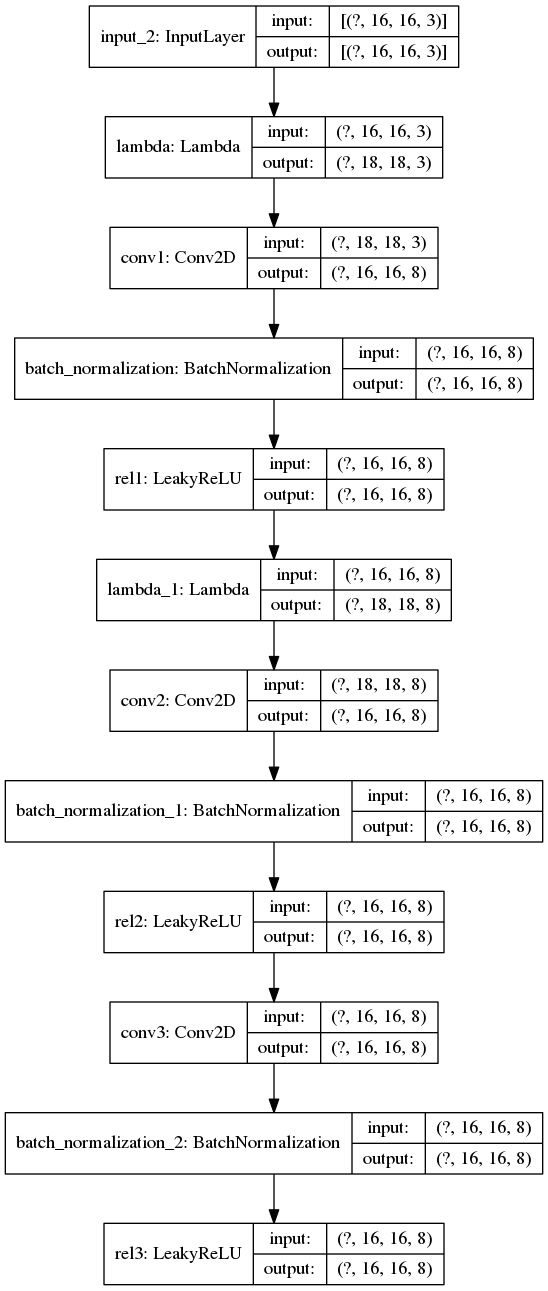

In [17]:
tf.keras.utils.plot_model(model, show_shapes=True)

In the function `conv_block`, we take the height and width of the input tensor and the number of channels of the input tensor, and the number of filters to finally output after processing. Note that, after each of the Circular Convolution, we perform a Batch Normalization and a Leaky ReLU layer. 

Batch Normalization layer basically normalizes the outputs with respect to the batch axis (i.e. with respect to the ? or None axis indicated in the diagram, which means you are pass arbitrary number of images through the network) so that the mean values remain close to 0, and standard deviation remains close to 1. The following image from the [2018 paper on Group Normalization](https://arxiv.org/abs/1803.08494) by Yuxin Wu, Kaiming He described the idea of normalization through the following interesting image.

<img src="norm.png">

Finally, Leaky ReLU is a layer than performs an nonlinear activation to the input vector. Leaky ReLU is basically the following function;

$$f(x) = \begin{cases}
x & \text{ if } x \geq 0\\
\alpha x & \text{ if } x < 0\\
\end{cases}$$

where $\alpha < 1$ is a non-trainable constant. It is usually fixed at a very low value like $0.05$ or $0.01$. Compared to that, ReLU function is similar to Leaky ReLU, but it outputs 0 if $x < 0$. Hence, Leaky ReLU is essentially a leaky version of ReLU, as it leaks out some small value for negative arguments. Since, such nonlinearity does not require additional parameters, we see 0 in the above summary output.

### Designing Join Block

In [18]:
def join_block(input_size, n_filter_low, n_filter_high):
    input1 = tf.keras.layers.Input((input_size, input_size, n_filter_low, ))  # input to low resolution image
    input2 = tf.keras.layers.Input((2*input_size, 2*input_size, n_filter_high, ))  # input to high resolution image
    upsampled_input = tf.keras.layers.UpSampling2D(size = (2, 2))(input1)
    hidden_1 = tf.keras.layers.BatchNormalization()(upsampled_input)
    hidden_2 = tf.keras.layers.BatchNormalization()(input2)
    
    outputs = tf.keras.layers.Concatenate(axis=-1)([hidden_1, hidden_2])
    
    # final model
    join_block = tf.keras.models.Model([input1, input2], outputs)
    return join_block

In [19]:
model = join_block(128, 32, 8)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 128, 128, 32 0                                            
__________________________________________________________________________________________________
up_sampling2d (UpSampling2D)    (None, 256, 256, 32) 0           input_3[0][0]                    
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 256, 256, 8) 0                                            
__________________________________________________________________________________________________
batch_normalization_3 (BatchNor (None, 256, 256, 32) 128         up_sampling2d[0][0]              
____________________________________________________________________________________________

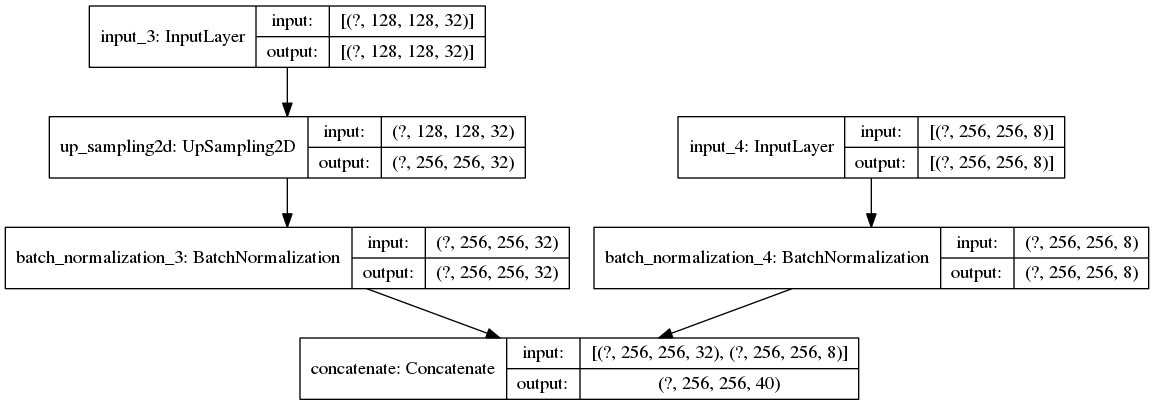

In [20]:
tf.keras.utils.plot_model(model, show_shapes=True)

The `join block` is extremely simple, it upsamples the low resolution processed features of the image. Then it normalizes both the higher resolution processed noise, and upsampled version of low resolution features, so that the effect of both branches remain comparable in the network. Finally, it combines the normalized versions.

### Completing the Generator

According to the [paper](https://arxiv.org/abs/1603.03417) describing Texture Networks, the generator should have a structure similar to the following figure.

<img src="gen.png">

However, it was also mentioned that for style transfer, increasing the number of noise from 5 to 6, actually provides much better quality. So, we start the network from a noise of size 8x8x3, and keep increasing it till 256x256x3, which is of the same size of our original content image.

In [21]:
def generator_network():
    # create input nodes for noise tensors
    noise1 = tf.keras.layers.Input((256, 256, 3, ), name = 'noise_1')
    noise2 = tf.keras.layers.Input((128, 128, 3, ), name = 'noise_2')
    noise3 = tf.keras.layers.Input((64, 64, 3, ), name = 'noise_3')
    noise4 = tf.keras.layers.Input((32, 32, 3, ), name = 'noise_4')
    noise5 = tf.keras.layers.Input((16, 16, 3, ), name = 'noise_5')
    noise6 = tf.keras.layers.Input((8, 8, 3, ), name = 'noise_6')
    content = tf.keras.layers.Input((256, 256, 3, ), name = 'content_input')

    # downsample the content image
    content_image_8 = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, tf.constant([8, 8])))(content)
    content_image_16 = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, tf.constant([16, 16])))(content)
    content_image_32 = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, tf.constant([32, 32])))(content)
    content_image_64 = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, tf.constant([64, 64])))(content)
    content_image_128 = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, tf.constant([128, 128])))(content)
    
    # create concatenation of downsampled content image and input nodes
    noise6_con = tf.keras.layers.Concatenate(axis=-1)([noise6, content_image_8])
    noise5_con = tf.keras.layers.Concatenate(axis=-1)([noise5, content_image_16])
    noise4_con = tf.keras.layers.Concatenate(axis=-1)([noise4, content_image_32])
    noise3_con = tf.keras.layers.Concatenate(axis=-1)([noise3, content_image_64])
    noise2_con = tf.keras.layers.Concatenate(axis=-1)([noise2, content_image_128])
    noise1_con = tf.keras.layers.Concatenate(axis=-1)([noise1, content])
    
    noise6_conv = conv_block(8, 6, 8)(noise6_con)   # that produces 8x8x8 tensor
    noise5_conv = conv_block(16, 6, 8)(noise5_con)   # that produces 16x16x8 tensor
    join5 = join_block(8, 8, 8)([noise6_conv, noise5_conv])   # that produces 16x16x16 tensor
    
    join5_conv = conv_block(16, 16, 16)(join5)   # produces 16x16x16 tensor
    noise4_conv = conv_block(32, 6, 8)(noise4_con)   # that produces 32x32x8 tensor
    join4 = join_block(16, 16, 8)([join5_conv, noise4_conv])   # produces 32x32x24 tensor
    
    join4_conv = conv_block(32, 24, 24)(join4)   # produces 32x32x24 tensor
    noise3_conv = conv_block(64, 6, 8)(noise3_con)  # that produces 64x64x8 tensor
    join3 = join_block(32, 24, 8)([join4_conv, noise3_conv])   # produces 64x64x32 tensor
    
    join3_conv = conv_block(64, 32, 32)(join3)   # produces 64x64x32 tensor
    noise2_conv = conv_block(128, 6, 8)(noise2_con)  # that produces 128x128x8 tensor
    join2 = join_block(64, 32, 8)([join3_conv, noise2_conv])   # produces 128x128x40 tensor
    
    join2_conv = conv_block(128, 40, 40)(join2)   # produces 128x128x40 tensor
    noise1_conv = conv_block(256, 6, 8)(noise1_con)  # that produces 256x256x8 tensor
    join1 = join_block(128, 40, 8)([join2_conv, noise1_conv])   # produces 256x256x48 tensor
    
    output = conv_block(256, 48, 3)(join1)   # produces 256x256x3 tensor
    
    model = tf.keras.models.Model([content, noise1, noise2, noise3, noise4, noise5, noise6], output, name = 'generator')
    
    return model

In [22]:
generator = generator_network()

In [23]:
generator.summary()

Model: "generator"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
content_input (InputLayer)      [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
noise_6 (InputLayer)            [(None, 8, 8, 3)]    0                                            
__________________________________________________________________________________________________
lambda_2 (Lambda)               (None, 8, 8, 3)      0           content_input[0][0]              
__________________________________________________________________________________________________
noise_5 (InputLayer)            [(None, 16, 16, 3)]  0                                            
__________________________________________________________________________________________

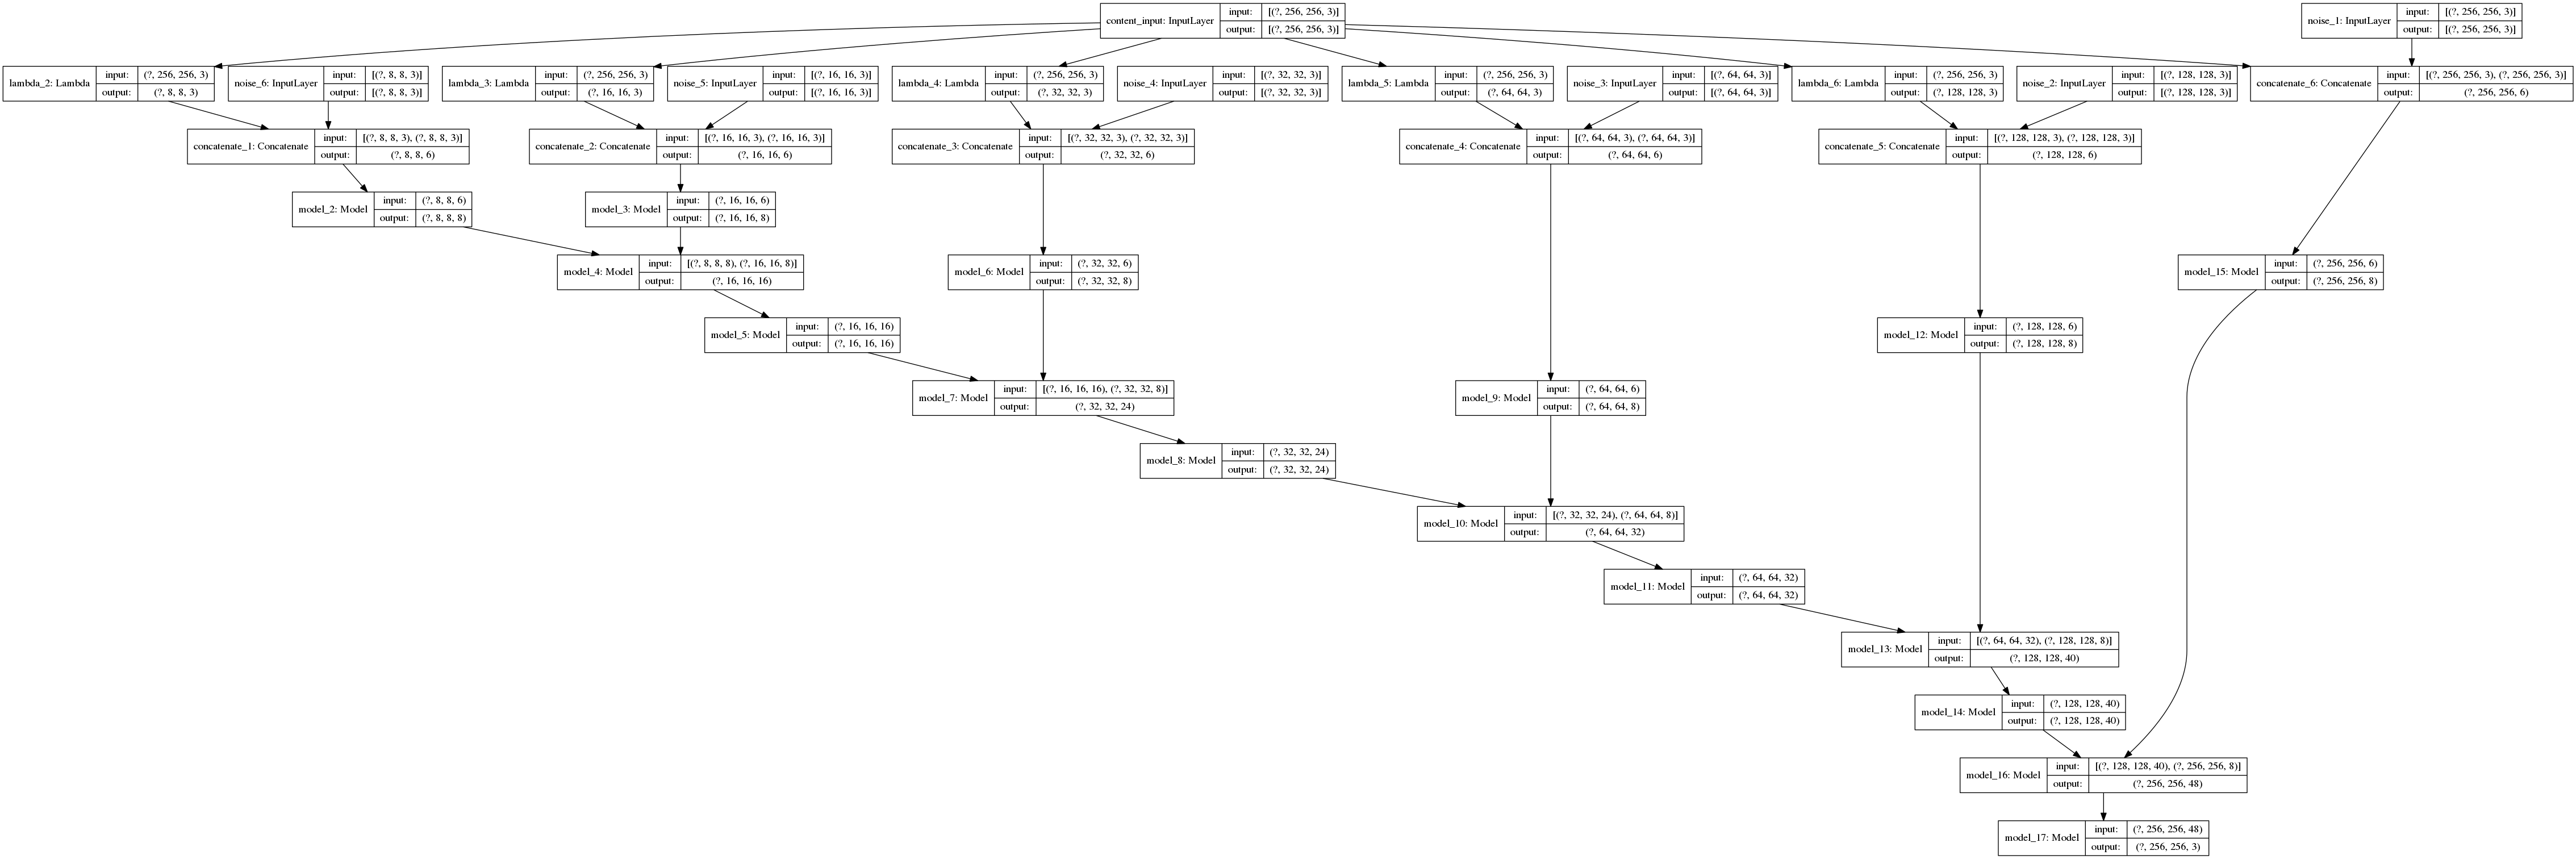

In [24]:
tf.keras.utils.plot_model(generator, show_shapes = True)

Finally, we have a generator model with about 75,000 parameters.

It should be clear that the low level features, i.e. the outputs of the lower level (closer to input layer that final layer in VGG19) layers are basically features such a strokes, edges which defines the artistic features of the image, whereas, high level features, i.e. the outputs of the higher level (closer to final layer than input layer in VGG19) are features that contains the summarization of the image, namely the abstract object that image contains, specifically the content of the image.

However, Gatys et al. in their [paper](https://arxiv.org/abs/1508.06576) **A Neural Algorithm for Artistic Style** depicts that the style is basically represented by the correlation of the low level features of an image, rather than the particular output of those low level features. An intuitive explanation to this particular observation can be given as follows: Consider our style image to be an image of a floor covered with square tiles, like a chessboard. Now, think of applying this tiling style to a complicated image of a landscape. To do this, one may need to consider rotating the tiles to be in a shape like diamonds, which may be able to capture better details of some corners presented in the content image. In this case, if we have a vertical and horizontal line detecting kernels as well as criss-cross line detecting kernels in VGG19, then such a pattern would not give similar output for both style image and final stylized image, but would give similar amount of correlation between those features.

Based on this idea, Gatys et al. introduced **Gram Matrix** to measure the style of an image. Let us particularly concentration on one such low level layer first, for which we have a output tensor of shape (batch size, height of the image, width of the image, number of filters output). Then the corresponding gram matrix of this layer is defined as a matrix of shape (batch size, height of the image, width of the image), whose elements are given by;

$$G_{bij} = \dfrac{\sum_c \sum_d X_{bijc} X_{bijd}}{HW}$$

where $X$ is the output tensor of that layer, $H, W$ denoting the height and width of the images. This formula can be implemented by `tf.linalg.einsum` function available in `tensorflow`, which performs the sum operation (of the numerator here) based on a given equation.

In [25]:
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)   # compute the sum in numerator
    input_shape = tf.shape(input_tensor)  # get the shape
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)  
    return result/(num_locations)

Now, I create a function called `vgg_layers` which returns our descriptor network, given the name of layers of VGG19 network which will be used to compute content and style of the image outputted by Generator Network. 

Furthermore, a class called `TextureNetwork` is created, which is inherited from `tf.keras.models.Model`. `tf.keras.models.Model` is a basic class to build new type of neural network model in `keras`. Inheritence allows us to automatically defines several properties of the keras model, in order to perform optimization and necessary computation in the training stage. Any object of `TextureNetwork` class is a Texture Network, initialized by specified names of content layers and style layers. Also, the `call` method of the class has been overridden from call method of `tf.keras.models.Model` class, which allows to define the exact workflow of feed forward system of our Texture Network. It finally outputs the generated image, along with the content output and style outputs (i.e. the gram matrices for style layers), which we can use to compute the loss function.

In [26]:
def vgg_layers(layer_names):
    """ Creates a vgg model that returns a list of intermediate output values."""
    # Load our model. Load pretrained VGG, trained on imagenet data
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')  # load the vgg model
    vgg.trainable = False    # do not train over vgg model parameters
  
    outputs = [vgg.get_layer(name).output for name in layer_names]    # the output of the layers that we want

    model = tf.keras.Model([vgg.input], outputs)   # create a keras model
    return model


class TextureNetwork(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super(TextureNetwork, self).__init__()   # initialize the superClass
        self.vgg =  vgg_layers(style_layers + content_layers)    # obtain a VGG19 model with outputs being the style and content layers
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False  # we are not going to train vgg network

        self.gen = generator_network()   # create a generator network as part of it
        self.gen.trainable = True   # we are going to train this generator
        

    def call(self, content, batch_size = 16):
        # generates noise required for the network
        noise1 = tf.random.uniform((batch_size, 256, 256, 3))
        noise2 = tf.random.uniform((batch_size, 128, 128, 3))
        noise3 = tf.random.uniform((batch_size, 64, 64, 3))
        noise4 = tf.random.uniform((batch_size, 32, 32, 3))
        noise5 = tf.random.uniform((batch_size, 16, 16, 3))
        noise6 = tf.random.uniform((batch_size, 8, 8, 3))
    
        gen_image = self.gen([content, noise1, noise2, noise3, noise4, noise5, noise6])   # pass through the generator to obtain generated image
    
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(gen_image)  # preprocess the image
        outputs = self.vgg(preprocessed_input)  # get the output from only the required layers
        
        style_outputs, content_outputs = (outputs[:self.num_style_layers], 
                                      outputs[self.num_style_layers:])
        
        style_outputs = [gram_matrix(style_output)
                         for style_output in style_outputs]  # create style type output to compare

        style_dict = {style_name:value
                      for style_name, value
                      in zip(self.style_layers, style_outputs)}

        content_dict = {content_name:value 
                    for content_name, value 
                    in zip(self.content_layers, content_outputs)}


        return {'gen':gen_image, 'content':content_dict, 'style':style_dict}

Now that we have defined our Texture Network class, we need to specify exactly which layers we are going to use for style features. According to the [paper](https://arxiv.org/abs/1603.03417) on Texture Network, the style layers should be *rel1_1, rel2_1, rel3_1, rel4_1*, while the content layer should be *rel4_2*. To compare it with the naming convention of VGG19, replace *rel* with *block* and add the convolution layer specified. However, I decided to add layer *block5_conv2*, since according to Gatys et al. this layer has good features related to the content, and for the style image, we can get the tessellation effect accurately by using this particular layer. However, you are welcome to try different layers, which may result in interesting stylized images. 

In [27]:
style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv2']
content_layers = ['block4_conv2']

In [28]:
optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3)  # use an Adam optimizer
tex_net = TextureNetwork(style_layers, content_layers)   # create the texture network

Note that, since the initial weights are set to 0, or close to 0, the illiterate network produces a black image. So, let us teach the network to learn its trainable parameters and weights, so that it can produces meaningful outputs.

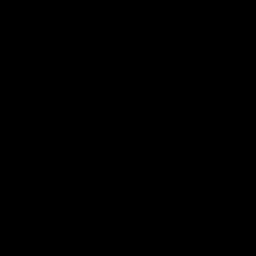

In [29]:
output = tex_net(content_image, 1)
tensor_to_image(output['gen'])

Before training, we require the target variables, based on which our network compares its performance and computes the loss function. In the [paper](https://arxiv.org/abs/1603.03417) on Texture Network, the author trains this network on MS COCO and ImageNet dataset. However, we shall use only the content and style image that we have repeatedly, since training on those large datasets would take particularly large amount of time and much computational power, which I lack because of scarcity of funds. So, I shall feed in the same content image and style image to the network repeatedly, and hope that the random noise inputs to the network is going to prevent overfitting of the network.

So, I define a function called `extract targets` which will extract the style and content from the style and content images, and then those values can be used to compute the loss function. To explicity write the loss function, we shall use the formula;

$$L = w_c \times L_c + w_s \times \sum_{k} L_{s_k}$$

where $L_c$ is the content loss, computed as the mean squared error between the content tensor of content image and the content tensor of generated image. $L_{s_k}$ is similar mean squared error between the gram matix of style image and gram matrix of generated image at $k$-th style layer, and $w_c$ and $w_s$ denotes the weights corresponding to content and style loss.

In [30]:
def extract_targets(inputs):
    inputs = inputs*255.0
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)  # preprocess the input image
    outputs = vgg_layers(style_layers + content_layers)(preprocessed_input)  # get the output from only the required layers
        
    style_outputs, content_outputs = (outputs[:len(style_layers)], 
                                       outputs[len(style_layers):])
        
    style_outputs = [gram_matrix(style_output)
                         for style_output in style_outputs]  # create style type output to compare

    style_dict = {style_name:value
                      for style_name, value
                      in zip(style_layers, style_outputs)}

    content_dict = {content_name:value 
                    for content_name, value 
                    in zip(content_layers, content_outputs)}

    return {'content':content_dict, 'style':style_dict}

In [31]:
style_targets = extract_targets(style_image)['style']
content_targets = extract_targets(content_image)['content']

In [32]:
style_weight = 1e-5
content_weight = 1

This particular choice to style and content weights seems to work for me pretty well. However, you are encouraged to try out different style and content weight combination to dig up more interesting findings.

In [33]:
def custom_loss(outputs, batch_size):
    gen_outputs = outputs['gen']
    style_outputs = outputs['style']   # for generated image, get the style
    content_outputs = outputs['content']  # get content
    batch_loss = 0
    for i in range(batch_size):
        style_loss = tf.add_n([tf.reduce_mean((style_outputs[name][i]-style_targets[name])**2) 
                           for name in style_outputs.keys()])
        style_loss *= style_weight / len(style_layers)

        content_loss = tf.add_n([tf.reduce_mean((content_outputs[name][i]-content_targets[name])**2) 
                                 for name in content_outputs.keys()])
        content_loss *= content_weight / len(content_layers)
        
        loss = style_loss + content_loss
        batch_loss += loss
        
    batch_loss /= batch_size
    return batch_loss

Finally, we define our `train_step` method, which performs one step of training of the Texture Network. The `tf.function` decorator used for the function actually converts this function and underlying object to tensorflow graph, based on which we can perform the feed forward pass as well as compute the gradients based on back propagation. Defining this decorator is essential for the training. More details on this is available at [Tensorflow website](https://www.tensorflow.org/tutorials/customization/performance).

In the `train_step` function, we use `tf.GradientTape` to record the feed forward passes through the network. It works like computing a recording of the feed forward pass through the model, and finally playing it backwards, in order to perform back propagation. This gradient tape records all the gradients happening through the graph, and finally enables us to apply the training rule to update the current value of the parameters using these gradients by `apply_gradients` function.

In [34]:
@tf.function()
def train_step(content_image, batch_size):
    
    with tf.GradientTape() as tape:
        outputs = tex_net(content_image, batch_size)
        loss = custom_loss(outputs, batch_size)
        
    gradients = tape.gradient(loss, tex_net.trainable_variables)  # obtain the gradients recorded by the tape
    optimizer.apply_gradients(zip(gradients, tex_net.trainable_variables))   # apply the training rule using the gradients to modify the current value of prameters
    return output, loss

Finally, I used 2500 iterations of update to train the network. I also show the images generated by the network after each 250 iterations, to see how the network improves over training.

Epoch: 0
Loss:  tf.Tensor(27138224.0, shape=(), dtype=float32)
Loss:  tf.Tensor(26169034.0, shape=(), dtype=float32)
Loss:  tf.Tensor(26064738.0, shape=(), dtype=float32)
Loss:  tf.Tensor(26034120.0, shape=(), dtype=float32)
Loss:  tf.Tensor(26004590.0, shape=(), dtype=float32)
Loss:  tf.Tensor(24625778.0, shape=(), dtype=float32)
Loss:  tf.Tensor(22932934.0, shape=(), dtype=float32)
Loss:  tf.Tensor(22210894.0, shape=(), dtype=float32)
Loss:  tf.Tensor(21038836.0, shape=(), dtype=float32)
Loss:  tf.Tensor(19649052.0, shape=(), dtype=float32)


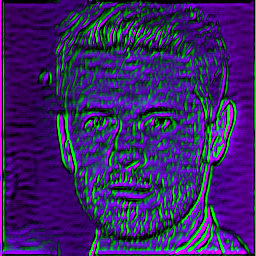

Epoch: 1
Loss:  tf.Tensor(16565710.0, shape=(), dtype=float32)
Loss:  tf.Tensor(13611194.0, shape=(), dtype=float32)
Loss:  tf.Tensor(12152441.0, shape=(), dtype=float32)
Loss:  tf.Tensor(11187487.0, shape=(), dtype=float32)
Loss:  tf.Tensor(10576777.0, shape=(), dtype=float32)
Loss:  tf.Tensor(9360093.0, shape=(), dtype=float32)
Loss:  tf.Tensor(8675145.0, shape=(), dtype=float32)
Loss:  tf.Tensor(8301968.0, shape=(), dtype=float32)
Loss:  tf.Tensor(7836261.0, shape=(), dtype=float32)
Loss:  tf.Tensor(7389797.5, shape=(), dtype=float32)


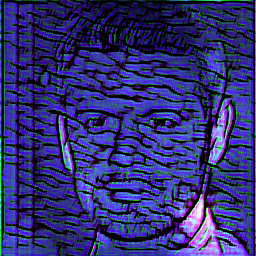

Epoch: 2
Loss:  tf.Tensor(7004705.0, shape=(), dtype=float32)
Loss:  tf.Tensor(6608028.0, shape=(), dtype=float32)
Loss:  tf.Tensor(6266657.5, shape=(), dtype=float32)
Loss:  tf.Tensor(6142354.0, shape=(), dtype=float32)
Loss:  tf.Tensor(5814227.0, shape=(), dtype=float32)
Loss:  tf.Tensor(5569461.0, shape=(), dtype=float32)
Loss:  tf.Tensor(5358932.5, shape=(), dtype=float32)
Loss:  tf.Tensor(5086491.0, shape=(), dtype=float32)
Loss:  tf.Tensor(4859027.0, shape=(), dtype=float32)
Loss:  tf.Tensor(4643354.0, shape=(), dtype=float32)


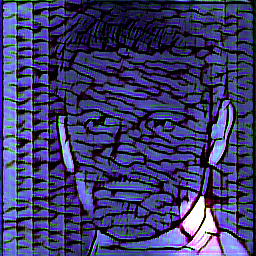

Epoch: 3
Loss:  tf.Tensor(4957266.0, shape=(), dtype=float32)
Loss:  tf.Tensor(4299568.5, shape=(), dtype=float32)
Loss:  tf.Tensor(4091998.8, shape=(), dtype=float32)
Loss:  tf.Tensor(4018616.8, shape=(), dtype=float32)
Loss:  tf.Tensor(3923811.2, shape=(), dtype=float32)
Loss:  tf.Tensor(3894964.5, shape=(), dtype=float32)
Loss:  tf.Tensor(3704813.2, shape=(), dtype=float32)
Loss:  tf.Tensor(3689166.5, shape=(), dtype=float32)
Loss:  tf.Tensor(3605529.8, shape=(), dtype=float32)
Loss:  tf.Tensor(3521357.8, shape=(), dtype=float32)


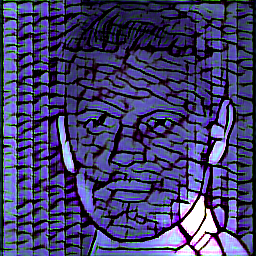

Epoch: 4
Loss:  tf.Tensor(3489987.0, shape=(), dtype=float32)
Loss:  tf.Tensor(3460784.0, shape=(), dtype=float32)
Loss:  tf.Tensor(3378974.0, shape=(), dtype=float32)
Loss:  tf.Tensor(3401102.8, shape=(), dtype=float32)
Loss:  tf.Tensor(3323982.8, shape=(), dtype=float32)
Loss:  tf.Tensor(3285243.0, shape=(), dtype=float32)
Loss:  tf.Tensor(3220874.8, shape=(), dtype=float32)
Loss:  tf.Tensor(3295160.2, shape=(), dtype=float32)
Loss:  tf.Tensor(3169093.5, shape=(), dtype=float32)
Loss:  tf.Tensor(3131125.2, shape=(), dtype=float32)


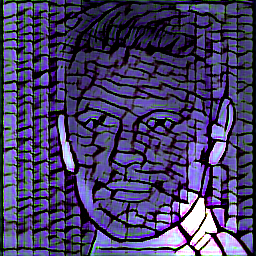

Epoch: 5
Loss:  tf.Tensor(3111150.5, shape=(), dtype=float32)
Loss:  tf.Tensor(3085978.8, shape=(), dtype=float32)
Loss:  tf.Tensor(3064475.2, shape=(), dtype=float32)
Loss:  tf.Tensor(3012352.0, shape=(), dtype=float32)
Loss:  tf.Tensor(2990475.0, shape=(), dtype=float32)
Loss:  tf.Tensor(2958282.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2929994.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2923794.8, shape=(), dtype=float32)
Loss:  tf.Tensor(2887351.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2852276.8, shape=(), dtype=float32)


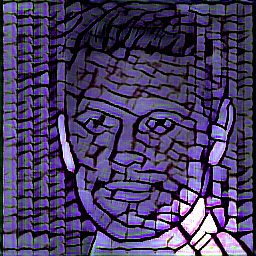

Epoch: 6
Loss:  tf.Tensor(2829871.8, shape=(), dtype=float32)
Loss:  tf.Tensor(2833075.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2788235.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2777346.8, shape=(), dtype=float32)
Loss:  tf.Tensor(2735421.0, shape=(), dtype=float32)
Loss:  tf.Tensor(2742302.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2696765.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2700100.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2741282.8, shape=(), dtype=float32)
Loss:  tf.Tensor(3431759.8, shape=(), dtype=float32)


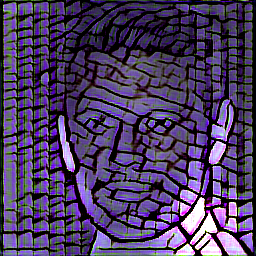

Epoch: 7
Loss:  tf.Tensor(2922398.0, shape=(), dtype=float32)
Loss:  tf.Tensor(2783216.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2718686.0, shape=(), dtype=float32)
Loss:  tf.Tensor(2677556.8, shape=(), dtype=float32)
Loss:  tf.Tensor(2645984.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2625516.8, shape=(), dtype=float32)
Loss:  tf.Tensor(2597460.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2577406.0, shape=(), dtype=float32)
Loss:  tf.Tensor(2555875.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2537895.5, shape=(), dtype=float32)


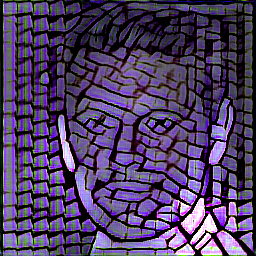

Epoch: 8
Loss:  tf.Tensor(2528999.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2511399.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2496434.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2484290.0, shape=(), dtype=float32)
Loss:  tf.Tensor(2472602.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2465217.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2449646.8, shape=(), dtype=float32)
Loss:  tf.Tensor(2445076.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2431088.0, shape=(), dtype=float32)
Loss:  tf.Tensor(2422472.8, shape=(), dtype=float32)


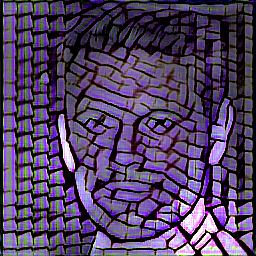

Epoch: 9
Loss:  tf.Tensor(2416303.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2413389.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2430066.5, shape=(), dtype=float32)
Loss:  tf.Tensor(3215110.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2591146.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2484897.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2440708.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2416797.5, shape=(), dtype=float32)
Loss:  tf.Tensor(2400430.2, shape=(), dtype=float32)
Loss:  tf.Tensor(2389489.8, shape=(), dtype=float32)


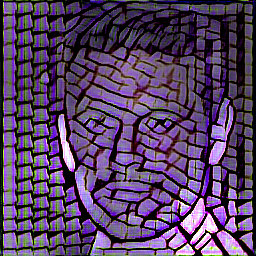

In [35]:
batch_size = 32
my_content = tf.concat([content_image for _ in range(batch_size)], axis = 0)

n_epoch = 10
n_iter = 250
iter_to_show_output = 25

loss_array = []
for epoch in range(n_epoch):
    msg = 'Epoch: ' + str(epoch)
    print(msg)
    os.system('echo ' + msg)
    for step in range(n_iter):
        outputs, loss = train_step(my_content, batch_size)
        if step % iter_to_show_output == 0:
            os.system('echo loss: ' + str(float(loss)))
            print('Loss: ', loss)
            loss_array.append(loss)
    display.display(tensor_to_image(tex_net(content_image, 1)['gen']))

Note how the generated image becomes better and better with more iteration, by mimicking the style of tessellation on our image of AI generated celebrity. But the image does not change much after epoch 5, except the colour gets more violet-ish rather than blue-ish. However, you can manipulate the style weights and content weights properly, in order to have a good balance between the content and style. Also, if we take a look at the loss function, we see that the loss was decreasing rapidly at the beginning, and finally it has more or less stabilized at a point where it cannot be lowered further by much. Hence, by looking at the loss function, it seems the generator is trained enough to meet its capacities.

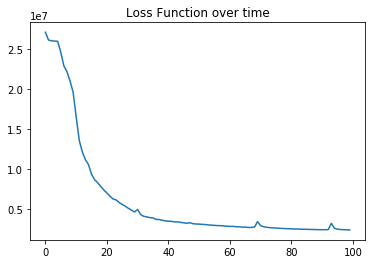

In [36]:
plt.plot(loss_array)
plt.title('Loss Function over time')
plt.show()

From the generation the final stylized image, it seems as if the image of the celebrity is properly tessellated, as we desired. However, it is mostly blue, and there are some funny artifacts and the colour of the skin appearing at the forehead area. This can possibly be resolved by carefully trying out different style and content layer repesentations, as well as adding a variational loss to the custom loss function.

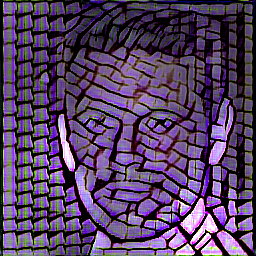

In [37]:
tensor_to_image(tex_net(content_image, 1)['gen'])

## Thank you very much for reading!